# MNIST Neural Network Classification Project
## Introduction

The goal of this project was to gain hands-on practice building neural networks in PyTorch and applying them to labelled datasets. To do this, I worked with the MNIST dataset, a classic benchmark dataset in machine learning that consists of grayscale images of handwritten digits from 0 to 9. Each image is only 28×28 pixels, yet the handwriting styles vary widely, making it a useful and challenging dataset for learning how neural networks behave.

Rather than focusing on pushing model accuracy as high as possible, the primary objective of this project was to build a complete deep learning workflow from start to finish. This includes exploring the dataset, designing a neural network, training and validating the model, saving the best version of the model, and evaluating its performance using visualizations and error analysis. MNIST provides an ideal environment for experimenting with these ideas and developing intuition about how neural networks learn from data.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
transform = transforms.ToTensor()

full_train_dataset = datasets.MNIST(
    root="./data", train=True, download=True, transform=transform
)

test_dataset = datasets.MNIST(
    root="./data", train=False, download=True, transform=transform
)

# Split training into train/validation
indices = list(range(len(full_train_dataset)))
train_idx, val_idx = train_test_split(indices, test_size=0.2, random_state=42)

train_dataset = Subset(full_train_dataset, train_idx)
val_dataset   = Subset(full_train_dataset, val_idx)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 40.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.20MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 11.0MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.68MB/s]


## Model and Training Approach

To perform digit classification, I trained a fully connected neural network that takes a flattened 28×28 image as input and outputs probabilities for each of the ten digit classes. The model consists of two hidden layers with ReLU activations, followed by an output layer that produces class scores (784 x 128 x 64 x 10).

The dataset was split into training, validation, and test sets. The model was trained using the Adam optimizer and cross-entropy loss. After each training epoch, I evaluated the model on the validation set, and the version of the model with the highest validation accuracy was saved. This ensured that the final model used for testing was the one that generalized best to unseen data.

In [3]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(28*28, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = x.view(x.size(0), -1)   # flatten
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        return self.fc3(x)

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Net().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 15
best_val_acc = 0.0

train_losses = []
val_losses = []
val_accuracies = []

for epoch in range(num_epochs):
    # ---- Training ----
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)

    # ---- Validation ----
    model.eval()
    correct = 0
    total = 0
    val_loss = 0.0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_loss /= len(val_loader)
    val_acc = correct / total

    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_mnist_model.pth")

    print(f"Epoch {epoch+1}/{num_epochs} | "
          f"Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | "
          f"Val Acc: {val_acc:.4f}")

Epoch 1/15 | Train Loss: 0.3759 | Val Loss: 0.1977 | Val Acc: 0.9433
Epoch 2/15 | Train Loss: 0.1571 | Val Loss: 0.1322 | Val Acc: 0.9604
Epoch 3/15 | Train Loss: 0.1100 | Val Loss: 0.1055 | Val Acc: 0.9677
Epoch 4/15 | Train Loss: 0.0838 | Val Loss: 0.0971 | Val Acc: 0.9709
Epoch 5/15 | Train Loss: 0.0648 | Val Loss: 0.0951 | Val Acc: 0.9718
Epoch 6/15 | Train Loss: 0.0530 | Val Loss: 0.0937 | Val Acc: 0.9714
Epoch 7/15 | Train Loss: 0.0420 | Val Loss: 0.0937 | Val Acc: 0.9738
Epoch 8/15 | Train Loss: 0.0325 | Val Loss: 0.0856 | Val Acc: 0.9752
Epoch 9/15 | Train Loss: 0.0286 | Val Loss: 0.0946 | Val Acc: 0.9748
Epoch 10/15 | Train Loss: 0.0253 | Val Loss: 0.0879 | Val Acc: 0.9763
Epoch 11/15 | Train Loss: 0.0160 | Val Loss: 0.0980 | Val Acc: 0.9739
Epoch 12/15 | Train Loss: 0.0178 | Val Loss: 0.1096 | Val Acc: 0.9735
Epoch 13/15 | Train Loss: 0.0134 | Val Loss: 0.1116 | Val Acc: 0.9739
Epoch 14/15 | Train Loss: 0.0140 | Val Loss: 0.1047 | Val Acc: 0.9765
Epoch 15/15 | Train Loss: 0.0

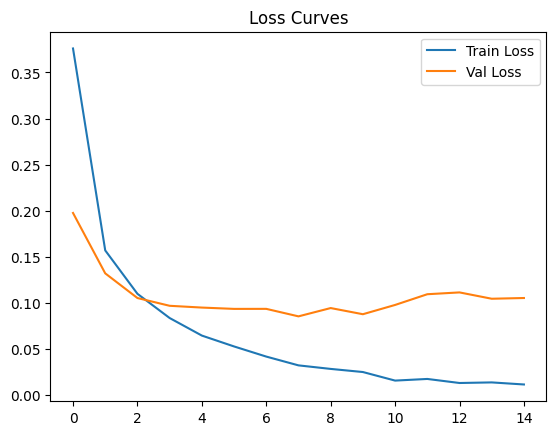

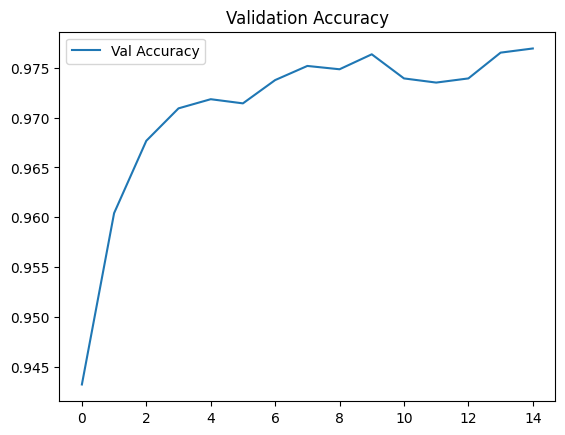

In [7]:
plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.legend()
plt.title("Loss Curves")
plt.show()

plt.figure()
plt.plot(val_accuracies, label="Val Accuracy")
plt.legend()
plt.title("Validation Accuracy")
plt.show()

## Training Results

Over the course of training, the model’s performance improved steadily. The training loss decreased rapidly during the first few epochs, indicating that the network quickly learned basic digit features such as edges and curves. Validation accuracy increased from approximately 94% after the first epoch to nearly 98% by the end of training.

The loss curves show a typical learning pattern: training loss continues to decrease while validation loss eventually plateaus and slightly increases, suggesting mild overfitting in later epochs. However, the validation accuracy remains consistently high, showing that the model generalizes well overall.

In [5]:
model.load_state_dict(torch.load("best_mnist_model.pth"))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_acc = np.mean(np.array(all_preds) == np.array(all_labels))
print("Test Accuracy:", test_acc)

Test Accuracy: 0.9765


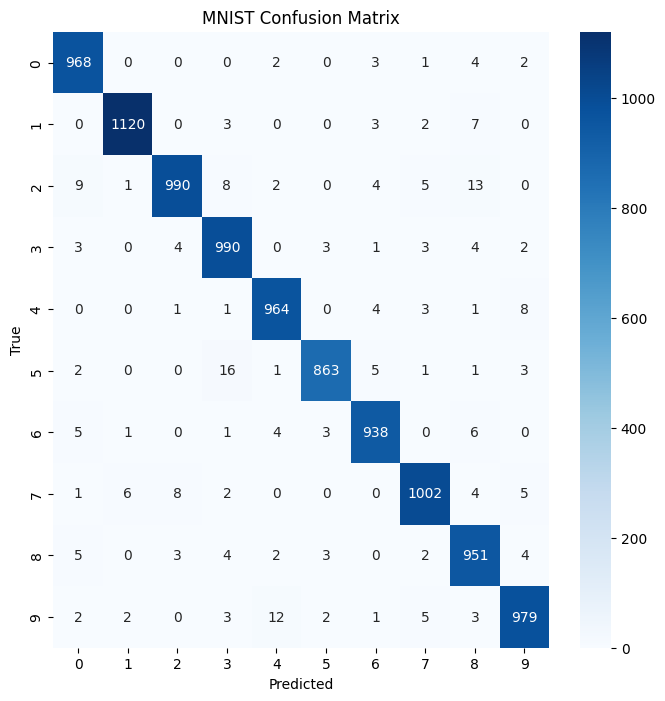

In [6]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("MNIST Confusion Matrix")
plt.show()

In [8]:
misclassified_images = []
misclassified_preds = []
misclassified_labels = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        for i in range(len(images)):
            if preds[i] != labels[i]:
                misclassified_images.append(images[i].cpu())
                misclassified_preds.append(preds[i].cpu().item())
                misclassified_labels.append(labels[i].cpu().item())


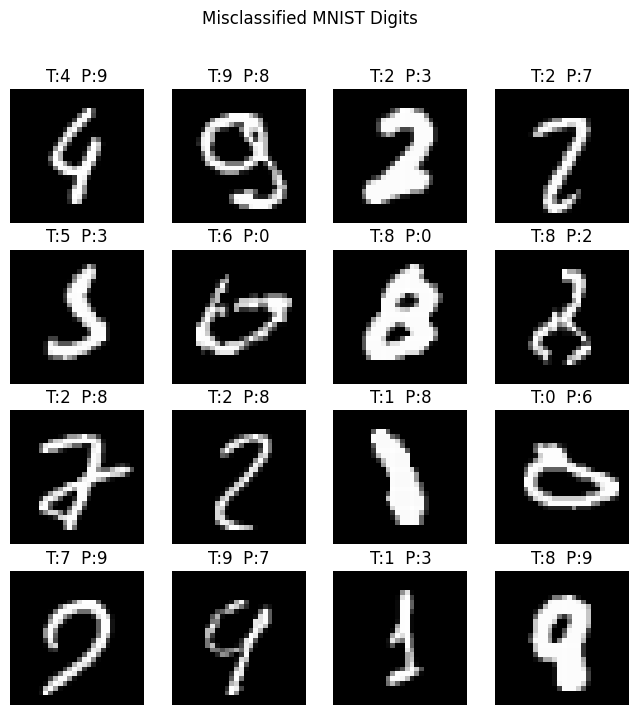

In [9]:
def show_misclassified(images, preds, labels, n=16):
    plt.figure(figsize=(8,8))
    for i in range(n):
        plt.subplot(4,4,i+1)
        plt.imshow(images[i].squeeze(), cmap="gray")
        plt.title(f"T:{labels[i]}  P:{preds[i]}")
        plt.axis("off")
    plt.suptitle("Misclassified MNIST Digits")
    plt.show()

show_misclassified(misclassified_images, misclassified_preds, misclassified_labels, n=16)


## Conclusions and Error Analysis

After training, I evaluated the best model checkpoint on the held-out test set, achieving a final accuracy of 97.65%. This confirms that the model is highly effective at recognizing handwritten digits despite their variability in style.

I also used a confusion matrix to analyze which digits were most frequently confused with one another. Most predictions lie along the diagonal of the matrix, meaning the vast majority of images were classified correctly. The most common errors occurred between visually similar digits such as 4 and 9, 5 and 3, and 2 and 7.

To further understand these mistakes, I visualized a selection of misclassified images. These examples mostly consist of ambiguous handwriting, incomplete strokes, or unusual styles that even a human might struggle to interpret. These misclassifications highlight the inherent difficulty of handwriting recognition and illustrate the limits of a simple fully connected network.